In [ ]:
!pip install numpy pandas scikit-learn torch pytorch-tabnet shap lime tabtransformertf

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 275.7/275.7 kB 5.0 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.5/44.5 kB 671.2 kB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 540.1/540.1 kB 13.0 MB/s eta 0:00:00
  Created wheel for lime: filename=lime-0.2.0.1-py3-none-any.whl size=283834 sha256=b0c73e742db5bfe06a9081b6e61fc930c02554b6c83fd9243b2af2cd28307835
  Stored in directory: /root/.cache/pip/wheels/fd/a2/af/9ac0a1a85a27f314a06b39e1f492bee1547d52549a4606ed89
Successfully built lime


In [ ]:
import tensorflow as tf
from lime.lime_tabular import LimeTabularExplainer
import numpy as np
import pandas as pd
import seaborn as sns
from matplotlib import pyplot as plt

import sklearn as sk
from sklearn.impute import SimpleImputer
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.linear_model import LogisticRegression
import lightgbm as lgb
from sklearn.model_selection import cross_val_score

from sklearn.metrics import roc_curve
from sklearn.metrics import roc_auc_score
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
from sklearn.metrics import precision_score, recall_score, f1_score, accuracy_score, roc_auc_score
import shap

from sklearn.model_selection import GridSearchCV
import torch.nn as nn
from pytorch_tabnet.tab_model import TabNetClassifier
from sklearn.feature_selection import mutual_info_classif

from tabtransformertf.utils.preprocessing import df_to_dataset, build_categorical_prep
from tabtransformertf.models.fttransformer import FTTransformerEncoder, FTTransformer
from tabtransformertf.models.tabtransformer import TabTransformer

from torch.utils.data import DataLoader, TensorDataset

/usr/local/lib/python3.10/dist-packages/dask/dataframe/__init__.py:42: FutureWarning: 
Dask dataframe query planning is disabled because dask-expr is not installed.

You can install it with `pip install dask[dataframe]` or `conda install dask`.
This will raise in a future version.

  warnings.warn(msg, FutureWarning)


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

#*Data processing*
Frankfurt_dataset = pd.read_csv('frankfurt_diabetes.csv')
Frankfurt_dataset.head(10)

Mounted at /content/drive


,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,2,138,62,35,0,33.6,0.127,47,1
1,0,84,82,31,125,38.2,0.233,23,0
2,0,145,0,0,0,44.2,0.630,31,1
3,0,135,68,42,250,42.3,0.365,24,1
4,1,139,62,41,480,40.7,0.536,21,0
5,0,173,78,32,265,46.5,1.159,58,0
6,4,99,72,17,0,25.6,0.294,28,0
7,8,194,80,0,0,26.1,0.551,67,0
8,2,83,65,28,66,36.8,0.629,24,0
9,2,89,90,30,0,33.5,0.292,42,0


In [ ]:
import os
os.listdir()

['.config', 'drive', 'frankfurt_diabetes.csv', 'sample_data']

In [ ]:
from google.colab import files
files=files.upload()

In [ ]:
print(df_train.head())


NameError: name 'df_train' is not defined

In [ ]:
# version 2
# Columns to check for zero values
var_check_zero = ['Insulin', 'BMI', 'SkinThickness','BloodPressure','Glucose']
# Create a boolean series that counts the number of zero values in each row for specified columns
zero_count = (Frankfurt_dataset[var_check_zero] == 0).sum(axis=1)

In [ ]:
############################version 3
threshold2 = 2
filtered_df2 = Frankfurt_dataset[zero_count <= threshold2]
print(filtered_df2)
filtered_df2.describe()

#REMOVE OUTLIER
#HOW MANY OUTLIERS TO MAKE DECISION ON REMOVING FOR EACH VARIABLES
#PREGNANCIES >= 15 (REMOVE) 05
threshold_preg = 14
# Create a new column based on the condition
filtered_df2.loc[:,'pregnancies_outlier'] = np.where(filtered_df2['Pregnancies'] > threshold_preg, 1, 0)

# Sum the new column to count rows above the threshold
count_pregnancies_outlier = filtered_df2['pregnancies_outlier'].sum()
print(f"Number of observations's pregnancies above threshold: {count_pregnancies_outlier}")

# Filter the DataFrame based on the zero count
filtered_df2 = filtered_df2[filtered_df2['Pregnancies'] < 15]

# SKINTHICKNESS
threshold_skin = 50
# Create a new column based on the condition
filtered_df2.loc[:,'skin_outlier'] = np.where(filtered_df2['SkinThickness'] > threshold_skin, 1, 0)

# Sum the new column to count rows above the threshold
count_skin_outlier = filtered_df2['skin_outlier'].sum()
print(f"Number of observations's skin above threshold: {count_skin_outlier}")

# Filter the DataFrame based on the zero count
filtered_df2 = filtered_df2[filtered_df2['SkinThickness'] < 50]

# BMI >= 50 (REMOVE)
threshold_bmi = 51
# Create a new column based on the condition
filtered_df2.loc[:,'BMI_outlier'] = np.where(filtered_df2['BMI'] > threshold_bmi, 1, 0)

# Sum the new column to count rows above the threshold
count_BMI_outlier = filtered_df2['BMI_outlier'].sum()
print(f"Number of observations's BMI above threshold: {count_BMI_outlier}")

filtered_df2 = filtered_df2.drop(columns = ['pregnancies_outlier', 'skin_outlier', 'BMI_outlier'])
filtered_df2.describe()

# Filter the DataFrame based on the zero count
filtered_df2 = filtered_df2[filtered_df2['BMI'] < 51]


      Pregnancies  Glucose  BloodPressure  SkinThickness  Insulin   BMI  \
0               2      138             62             35        0  33.6   
1               0       84             82             31      125  38.2   
3               0      135             68             42      250  42.3   
4               1      139             62             41      480  40.7   
5               0      173             78             32      265  46.5   
...           ...      ...            ...            ...      ...   ...   
1995            2       75             64             24       55  29.7   
1996            8      179             72             42      130  32.7   
1997            6       85             78              0        0  31.2   
1998            0      129            110             46      130  67.1   
1999            2       81             72             15       76  30.1   

      DiabetesPedigreeFunction  Age  Outcome  
0                        0.127   47        1  
1    

<ipython-input-6-cdb71cf672c3>:12: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  filtered_df2.loc[:,'pregnancies_outlier'] = np.where(filtered_df2['Pregnancies'] > threshold_preg, 1, 0)


In [ ]:
#imputation with mean
#Variables selected for impute
var_impute = ['Glucose', 'BloodPressure', 'SkinThickness', 'Insulin', 'BMI']
# Define the SimpleImputer with mean strategy
mean_imputer = SimpleImputer(missing_values = 0, strategy='mean')

# Applying the mask to convert zeros to missing values
filtered_df2[var_impute] = mean_imputer.fit_transform(filtered_df2[var_impute])
filtered_df2.describe()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
count,1858.000000,1858.000000,1858.000000,1858.000000,1858.000000,1858.000000,1858.000000,1858.000000,1858.000000
mean,3.754575,121.775068,72.243521,28.502542,153.544088,32.181803,0.471336,33.199139,0.334230
std,3.258896,30.511186,11.960516,8.132063,80.894140,6.399865,0.318608,11.772487,0.471848
min,0.000000,44.000000,24.000000,7.000000,15.000000,18.200000,0.078000,21.000000,0.000000
25%,1.000000,99.000000,64.000000,24.000000,120.000000,27.425000,0.245250,24.000000,0.000000
50%,3.000000,117.000000,72.000000,28.502542,153.544088,32.000000,0.378000,29.000000,0.000000
75%,6.000000,141.000000,80.000000,32.000000,153.544088,36.300000,0.618000,41.000000,1.000000
max,14.000000,199.000000,122.000000,49.000000,744.000000,50.700000,2.329000,81.000000,1.000000


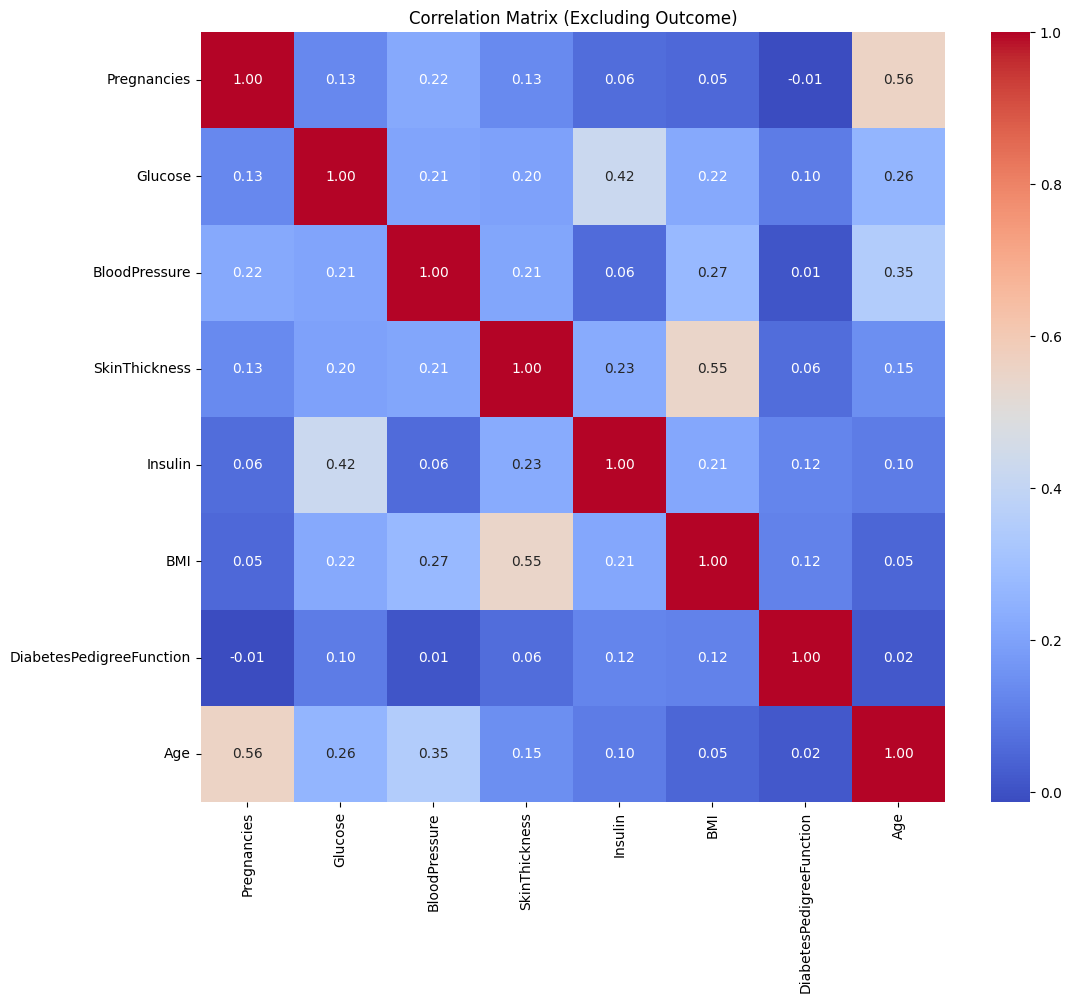

In [ ]:
# prompt: print heatmap correlation for data but not include "Outcome"variable and save figure with 1200 dpi and .eps

import matplotlib.pyplot as plt
import seaborn as sns

# Exclude 'Outcome' from the correlation calculation
correlation_matrix = filtered_df2.drop('Outcome', axis=1).corr()

# Create the heatmap
plt.figure(figsize=(12, 10))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Correlation Matrix (Excluding Outcome)')

# Save the figure with high DPI and .eps format
plt.savefig('correlation_heatmap.eps', dpi=1200, format='eps')

plt.show()


                          Pregnancies   Glucose  BloodPressure  SkinThickness  \
Pregnancies                  1.000000  0.132069       0.224242       0.133419   
Glucose                      0.132069  1.000000       0.206495       0.198668   
BloodPressure                0.224242  0.206495       1.000000       0.208826   
SkinThickness                0.133419  0.198668       0.208826       1.000000   
Insulin                      0.064873  0.423879       0.060940       0.227902   
BMI                          0.052081  0.220948       0.274737       0.546865   
DiabetesPedigreeFunction    -0.013217  0.101119       0.007592       0.062029   
Age                          0.559129  0.257191       0.348753       0.147937   
Outcome                      0.240730  0.486013       0.181440       0.221371   

                           Insulin       BMI  DiabetesPedigreeFunction  \
Pregnancies               0.064873  0.052081                 -0.013217   
Glucose                   0.423879  0.220

NameError: name 'mp' is not defined

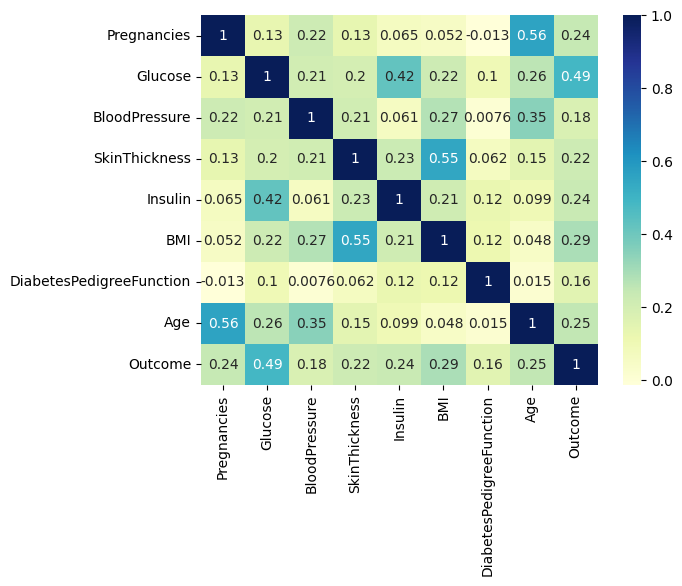

In [ ]:
print(filtered_df2.corr(numeric_only=True))

# Plotting correlation heatmap
dataplot = sns.heatmap(filtered_df2.corr(numeric_only=True), cmap="YlGnBu", annot=True)

# Displaying heatmap
mp.show()

In [ ]:
# prompt: how to recode into different Pregrancies variables from numeric type into ordinal category variable? from 0 - 2 = 1; 3 - 6 = 2; >= 7 = 3

import pandas as pd
import numpy as np
# Create a new column 'PregnancyCategory' based on the conditions
#filtered_df2['PregnancyCategory'] = pd.cut(filtered_df2['Pregnancies'], bins=[-float('inf'), 2, 6, float('inf')], labels=[1, 2, 3])

# Alternatively, using np.select for more control
# conditions = [
#     filtered_df2['Pregnancies'].between(0, 2),
#     filtered_df2['Pregnancies'].between(3, 6),
#     filtered_df2['Pregnancies'] >= 7
# ]
# choices = [1, 2, 3]
# filtered_df2['PregnancyCategory'] = np.select(conditions, choices, default=np.nan)

# Display the updated DataFrame
#print(filtered_df2[['Pregnancies', 'PregnancyCategory']].head(10))


    Pregnancies PregnancyCategory
0             2                 1
1             0                 1
3             0                 1
4             1                 1
5             0                 1
6             4                 2
7             8                 3
8             2                 1
9             2                 1
10            4                 2


In [ ]:
CATEGORICAL_FEATURES = ['Pregnancies']
NUMERIC_FEATURES = ['Glucose', 'BloodPressure', 'SkinThickness', 'Insulin', 'BMI', 'DiabetesPedigreeFunction', 'Age']
FEATURES = CATEGORICAL_FEATURES + NUMERIC_FEATURES
TARGET_FEATURE = 'Outcome'

In [ ]:
scaler = StandardScaler()
scaler.fit(filtered_df2[NUMERIC_FEATURES])
filtered_df2[NUMERIC_FEATURES]= scaler.transform(filtered_df2[NUMERIC_FEATURES]).astype('float32')
filtered_df2

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,2,0.531913,-0.856675,0.799208,0.000000,0.221658,-1.081040,1.172614,1
1,0,-1.238406,0.815944,0.307195,-0.352952,0.940616,-0.748254,-0.866587,0
3,0,0.433562,-0.354890,1.660230,1.192693,1.581427,-0.333841,-0.781620,1
4,1,0.564697,-0.856675,1.537227,4.036681,1.331355,0.203013,-1.036520,0
5,0,1.679342,0.481420,0.430198,1.378170,2.237868,2.158918,2.107247,0
...,...,...,...,...,...,...,...,...,...
1994,1,-1.402324,-1.023937,1.660230,-1.305070,1.768982,0.648821,-0.866587,0
1995,2,-1.533459,-0.689413,-0.553827,-1.218514,-0.387894,-0.318143,-0.016920,0
1996,8,1.876044,-0.020366,1.660230,-0.291126,0.080992,0.777540,0.237980,1
1997,6,-1.205622,0.481420,0.000000,0.000000,-0.153451,-0.280469,0.747780,0


In [ ]:
# Split the data into training and testing sets
X = filtered_df2.drop('Outcome', axis=1)
y = filtered_df2['Outcome']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)


In [ ]:
class FTTransformer(nn.Module):
    def __init__(self, numerical_features, categorical_cardinalities, d_model=128, nhead=4, num_layers=2, dim_feedforward=256):
        super(FTTransformer, self).__init__()

        # Embedding for categorical features
        self.embeddings = nn.ModuleList([
            nn.Embedding(cardinality, d_model) for cardinality in categorical_cardinalities
        ])

        # Linear layer to process numerical features
        self.numerical_linear = nn.Linear(len(numerical_features), d_model)

        # Transformer Encoder
        self.encoder_layer = nn.TransformerEncoderLayer(
            d_model=d_model,
            nhead=nhead,
            dim_feedforward=dim_feedforward
        )
        self.transformer_encoder = nn.TransformerEncoder(self.encoder_layer, num_layers=num_layers)

        # Final output layer for binary classification
        self.output_layer = nn.Linear(d_model, 1)

    def forward(self, numerical_data, categorical_data):
        # Embed the categorical data
        categorical_embeds = [
            embed(categorical_data[:, i]) for i, embed in enumerate(self.embeddings)
        ]

        # Concatenate the categorical embeddings
        categorical_embeds = torch.cat(categorical_embeds, dim=1)

        # Process numerical features through a linear layer
        numerical_embeds = self.numerical_linear(numerical_data)

        # Combine both categorical and numerical embeddings
        combined_embeds = numerical_embeds + categorical_embeds

        # Pass through the Transformer Encoder
        transformer_output = self.transformer_encoder(combined_embeds)

        # Apply the final output layer for binary classification
        output = self.output_layer(transformer_output)

        return torch.sigmoid(output)

In [ ]:
filtered_df2.info()

<class 'pandas.core.frame.DataFrame'>
Index: 1858 entries, 0 to 1999
Data columns (total 10 columns):
 #   Column                    Non-Null Count  Dtype   
---  ------                    --------------  -----   
 0   Pregnancies               1858 non-null   int64   
 1   Glucose                   1858 non-null   float32 
 2   BloodPressure             1858 non-null   float32 
 3   SkinThickness             1858 non-null   float32 
 4   Insulin                   1858 non-null   float32 
 5   BMI                       1858 non-null   float32 
 6   DiabetesPedigreeFunction  1858 non-null   float32 
 7   Age                       1858 non-null   float32 
 8   Outcome                   1858 non-null   int64   
 9   PregnancyCategory         1858 non-null   category
dtypes: category(1), float32(7), int64(2)
memory usage: 96.3 KB


In [ ]:
import torch.nn as nn
from torch.utils.data import TensorDataset, DataLoader
from sklearn.metrics import accuracy_score
import torch

class FTTransformer(nn.Module):
    def __init__(self, numerical_features, categorical_cardinalities, d_model=128, nhead=4, num_layers=2, dim_feedforward=256):
        super(FTTransformer, self).__init__()

        # Embedding for categorical features
        self.embeddings = nn.ModuleList([
            nn.Embedding(cardinality, d_model) for cardinality in categorical_cardinalities
        ])

        # Linear layer to process numerical features
        self.numerical_linear = nn.Linear(len(numerical_features), d_model)

        # Transformer Encoder
        self.encoder_layer = nn.TransformerEncoderLayer(
            d_model=d_model,
            nhead=nhead,
            dim_feedforward=dim_feedforward
        )
        self.transformer_encoder = nn.TransformerEncoder(self.encoder_layer, num_layers=num_layers)

        # Final output layer for binary classification
        self.output_layer = nn.Linear(d_model, 1)

    def forward(self, numerical_data, categorical_data):
        # Embed the categorical data
        categorical_embeds = [
            embed(categorical_data[:, i]) for i, embed in enumerate(self.embeddings)
        ]

        # Concatenate the categorical embeddings
        categorical_embeds = torch.cat(categorical_embeds, dim=1)

        # Process numerical features through a linear layer
        numerical_embeds = self.numerical_linear(numerical_data)

        # Combine both categorical and numerical embeddings
        combined_embeds = numerical_embeds + categorical_embeds

        # Pass through the Transformer Encoder
        transformer_output = self.transformer_encoder(combined_embeds)

        # Apply the final output layer for binary classification
        output = self.output_layer(transformer_output)

        return torch.sigmoid(output)

# Define the categorical cardinalities (number of unique values for each categorical feature). This is now outside the class definition
categorical_cardinalities = [filtered_df2['Pregnancies'].nunique()]

# Create the FTTransformer model
model = FTTransformer(
    numerical_features=NUMERIC_FEATURES,
    categorical_cardinalities=categorical_cardinalities
)

# Define the loss function and optimizer
criterion = nn.BCELoss()
optimizer = torch.optim.Adam(model.parameters(),lr=3e-5)

# Create a DataLoader for the training data
train_dataset = TensorDataset(
    torch.tensor(X_train[NUMERIC_FEATURES].values.astype('float32')),
    torch.tensor(X_train[CATEGORICAL_FEATURES].values.astype('int64')),
    torch.tensor(y_train.values.astype('float32'))
)
train_loader = DataLoader(train_dataset, batch_size=128, shuffle=True)

# Train the model with early stopping
num_epochs = 1000
early_stopping_patience = 10
best_val_accuracy = 0
epochs_no_improve = 0

for epoch in range(num_epochs):
    model.train()
    for numerical_data, categorical_data, labels in train_loader:
        optimizer.zero_grad()
        outputs = model(numerical_data, categorical_data).squeeze()
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
    print(f"Epoch [{epoch+1}/{num_epochs}], Loss: {loss.item():.4f}")


    # Evaluate on validation set (you'll need to split your training data further)
with torch.no_grad():
    numerical_data_test = torch.tensor(X_test[NUMERIC_FEATURES].values.astype('float32'))
    categorical_data_test = torch.tensor(X_test[CATEGORICAL_FEATURES].values.astype('int64'))
    test_outputs = model(numerical_data_test, categorical_data_test).squeeze()
    predicted_labels = (test_outputs > 0.5).int().numpy()
    accuracy = accuracy_score(y_test, predicted_labels)
    print(f"Test Accuracy: {accuracy:.4f}")




In [ ]:
import torch.nn as nn
from torch.utils.data import TensorDataset, DataLoader
from sklearn.metrics import accuracy_score
import torch

class FTTransformer(nn.Module):
    def __init__(self, numerical_features, categorical_cardinalities, d_model=128, nhead=4, num_layers=2, dim_feedforward=256):
        super(FTTransformer, self).__init__()

        # Embedding for categorical features
        self.embeddings = nn.ModuleList([
            nn.Embedding(cardinality, d_model) for cardinality in categorical_cardinalities
        ])

        # Linear layer to process numerical features
        self.numerical_linear = nn.Linear(len(numerical_features), d_model)

        # Transformer Encoder
        self.encoder_layer = nn.TransformerEncoderLayer(
            d_model=d_model,
            nhead=nhead,
            dim_feedforward=dim_feedforward
        )
        self.transformer_encoder = nn.TransformerEncoder(self.encoder_layer, num_layers=num_layers)

        # Final output layer for binary classification
        self.output_layer = nn.Linear(d_model, 1)

    def forward(self, numerical_data, categorical_data):
        # Embed the categorical data
        categorical_embeds = [
            embed(categorical_data[:, i]) for i, embed in enumerate(self.embeddings)
        ]

        # Concatenate the categorical embeddings
        categorical_embeds = torch.cat(categorical_embeds, dim=1)

        # Process numerical features through a linear layer
        numerical_embeds = self.numerical_linear(numerical_data)

        # Combine both categorical and numerical embeddings
        combined_embeds = numerical_embeds + categorical_embeds

        # Pass through the Transformer Encoder
        transformer_output = self.transformer_encoder(combined_embeds)

        # Apply the final output layer for binary classification
        output = self.output_layer(transformer_output)

        return torch.sigmoid(output)

# Define the categorical cardinalities (number of unique values for each categorical feature). This is now outside the class definition
categorical_cardinalities = [filtered_df2['Pregnancies'].nunique()]

# Create the FTTransformer model
model = FTTransformer(
    numerical_features=NUMERIC_FEATURES,
    categorical_cardinalities=categorical_cardinalities
)

# Define the loss function and optimizer
criterion = nn.BCELoss()
optimizer = torch.optim.Adam(model.parameters(),lr=0.001)

# Create a DataLoader for the training data
train_dataset = TensorDataset(
    torch.tensor(X_train[NUMERIC_FEATURES].values.astype('float32')),
    torch.tensor(X_train[CATEGORICAL_FEATURES].values.astype('int64')),
    torch.tensor(y_train.values.astype('float32'))
)
train_loader = DataLoader(train_dataset, batch_size=128, shuffle=True)

# Train the model with early stopping
num_epochs = 800
early_stopping_patience = 10
best_val_accuracy = 0
epochs_no_improve = 0

for epoch in range(num_epochs):
    model.train()
    for numerical_data, categorical_data, labels in train_loader:
        optimizer.zero_grad()
        outputs = model(numerical_data, categorical_data).squeeze()
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
    print(f"Epoch [{epoch+1}/{num_epochs}], Loss: {loss.item():.4f}")


    # Evaluate on validation set (you'll need to split your training data further)
with torch.no_grad():
    numerical_data_test = torch.tensor(X_test[NUMERIC_FEATURES].values.astype('float32'))
    categorical_data_test = torch.tensor(X_test[CATEGORICAL_FEATURES].values.astype('int64'))
    test_outputs = model(numerical_data_test, categorical_data_test).squeeze()
    predicted_labels = (test_outputs > 0.5).int().numpy()
    accuracy = accuracy_score(y_test, predicted_labels)
    print(f"Test Accuracy: {accuracy:.4f}")




/usr/local/lib/python3.10/dist-packages/torch/nn/modules/transformer.py:307: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.self_attn.batch_first was not True(use batch_first for better inference performance)
  warnings.warn(f"enable_nested_tensor is True, but self.use_nested_tensor is False because {why_not_sparsity_fast_path}")


Epoch [1/2000], Loss: 0.5728
Epoch [2/2000], Loss: 0.4616
Epoch [3/2000], Loss: 0.5692
Epoch [4/2000], Loss: 0.4574
Epoch [5/2000], Loss: 0.3847
Epoch [6/2000], Loss: 0.4675
Epoch [7/2000], Loss: 0.4225
Epoch [8/2000], Loss: 0.4282
Epoch [9/2000], Loss: 0.4509
Epoch [10/2000], Loss: 0.3551
Epoch [11/2000], Loss: 0.2991
Epoch [12/2000], Loss: 0.4388
Epoch [13/2000], Loss: 0.3571
Epoch [14/2000], Loss: 0.3021
Epoch [15/2000], Loss: 0.4923
Epoch [16/2000], Loss: 0.2864
Epoch [17/2000], Loss: 0.3845
Epoch [18/2000], Loss: 0.3257
Epoch [19/2000], Loss: 0.3362
Epoch [20/2000], Loss: 0.2741
Epoch [21/2000], Loss: 0.2864
Epoch [22/2000], Loss: 0.3450
Epoch [23/2000], Loss: 0.2489
Epoch [24/2000], Loss: 0.2238
Epoch [25/2000], Loss: 0.2796
Epoch [26/2000], Loss: 0.3005
Epoch [27/2000], Loss: 0.1752
Epoch [28/2000], Loss: 0.3279
Epoch [29/2000], Loss: 0.3484
Epoch [30/2000], Loss: 0.2061
Epoch [31/2000], Loss: 0.1712
Epoch [32/2000], Loss: 0.2069
Epoch [33/2000], Loss: 0.1230
Epoch [34/2000], Lo

KeyboardInterrupt: 

In [ ]:
# prompt: train model in learning rate = 0.001, epochs = 200, batch size = 128 and print accuracy of train data and test dat

from torch.utils.data import TensorDataset, DataLoader
import torch.nn as nn
import torch

# ... (Your previous code, including the FTTransformer class and data preparation) ...

# Define the categorical cardinalities (number of unique values for each categorical feature). This is now outside the class definition
categorical_cardinalities = [filtered_df2['Pregnancies'].nunique()]

# Create the FTTransformer model
model = FTTransformer(
    numerical_features=NUMERIC_FEATURES,
    categorical_cardinalities=categorical_cardinalities
)

# Define the loss function and optimizer
criterion = nn.BCELoss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)

# Create a DataLoader for the training data
train_dataset = TensorDataset(
    torch.tensor(X_train[NUMERIC_FEATURES].values.astype('float32')),
    torch.tensor(X_train[CATEGORICAL_FEATURES].values.astype('int64')),
    torch.tensor(y_train.values.astype('float32'))
)
train_loader = DataLoader(train_dataset, batch_size=128, shuffle=True)

# Train the model
num_epochs = 800

for epoch in range(num_epochs):
    model.train()
    for numerical_data, categorical_data, labels in train_loader:
        optimizer.zero_grad()
        outputs = model(numerical_data, categorical_data).squeeze()
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
    print(f"Epoch [{epoch+1}/{num_epochs}], Loss: {loss.item():.4f}")

    # Evaluate on training data
    model.eval()
    with torch.no_grad():
        numerical_data_train = torch.tensor(X_train[NUMERIC_FEATURES].values.astype('float32'))
        categorical_data_train = torch.tensor(X_train[CATEGORICAL_FEATURES].values.astype('int64'))
        train_outputs = model(numerical_data_train, categorical_data_train).squeeze()
        predicted_labels_train = (train_outputs > 0.5).int().numpy()
        train_accuracy = accuracy_score(y_train, predicted_labels_train)
        print(f"Train Accuracy: {train_accuracy:.4f}")


    # Evaluate on test data
    with torch.no_grad():
        numerical_data_test = torch.tensor(X_test[NUMERIC_FEATURES].values.astype('float32'))
        categorical_data_test = torch.tensor(X_test[CATEGORICAL_FEATURES].values.astype('int64'))
        test_outputs = model(numerical_data_test, categorical_data_test).squeeze()
        predicted_labels_test = (test_outputs > 0.5).int().numpy()
        test_accuracy = accuracy_score(y_test, predicted_labels_test)
        print(f"Test Accuracy: {test_accuracy:.4f}")


/usr/local/lib/python3.10/dist-packages/torch/nn/modules/transformer.py:307: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.self_attn.batch_first was not True(use batch_first for better inference performance)
  warnings.warn(f"enable_nested_tensor is True, but self.use_nested_tensor is False because {why_not_sparsity_fast_path}")


Epoch [1/800], Loss: 0.5408
Train Accuracy: 0.7779
Test Accuracy: 0.7581
Epoch [2/800], Loss: 0.5570
Train Accuracy: 0.7840
Test Accuracy: 0.7903
Epoch [3/800], Loss: 0.4088
Train Accuracy: 0.8015
Test Accuracy: 0.7876
Epoch [4/800], Loss: 0.4763
Train Accuracy: 0.8109
Test Accuracy: 0.7903
Epoch [5/800], Loss: 0.4633
Train Accuracy: 0.8223
Test Accuracy: 0.8011
Epoch [6/800], Loss: 0.3800
Train Accuracy: 0.8560
Test Accuracy: 0.8038
Epoch [7/800], Loss: 0.3930
Train Accuracy: 0.8553
Test Accuracy: 0.8280
Epoch [8/800], Loss: 0.3144
Train Accuracy: 0.8472
Test Accuracy: 0.8118
Epoch [9/800], Loss: 0.2632
Train Accuracy: 0.8560
Test Accuracy: 0.8118
Epoch [10/800], Loss: 0.2663
Train Accuracy: 0.8863
Test Accuracy: 0.8548
Epoch [11/800], Loss: 0.3634
Train Accuracy: 0.8890
Test Accuracy: 0.8683
Epoch [12/800], Loss: 0.2832
Train Accuracy: 0.8917
Test Accuracy: 0.8441
Epoch [13/800], Loss: 0.1914
Train Accuracy: 0.9024
Test Accuracy: 0.8629
Epoch [14/800], Loss: 0.3154
Train Accuracy: 0.

In [ ]:
# prompt: how about overall accuray of the model with 400 epochs

# Evaluate on the entire dataset (both train and test)
with torch.no_grad():
    numerical_data_all = torch.tensor(X[NUMERIC_FEATURES].values.astype('float32'))
    categorical_data_all = torch.tensor(X[CATEGORICAL_FEATURES].values.astype('int64'))
    all_outputs = model(numerical_data_all, categorical_data_all).squeeze()
    predicted_labels_all = (all_outputs > 0.5).int().numpy()
    overall_accuracy = accuracy_score(y, predicted_labels_all)
    print(f"Overall Accuracy: {overall_accuracy:.4f}")


Overall Accuracy: 0.9952


Epoch [1/800], Train Loss: 0.5588
Test Loss: 0.4888
Epoch [2/800], Train Loss: 0.4537
Test Loss: 0.4438
Epoch [3/800], Train Loss: 0.4257
Test Loss: 0.4325
Epoch [4/800], Train Loss: 0.4049
Test Loss: 0.4108
Epoch [5/800], Train Loss: 0.4018
Test Loss: 0.4245
Epoch [6/800], Train Loss: 0.3781
Test Loss: 0.3735
Epoch [7/800], Train Loss: 0.3586
Test Loss: 0.3807
Epoch [8/800], Train Loss: 0.3382
Test Loss: 0.4116
Epoch [9/800], Train Loss: 0.3392
Test Loss: 0.3539
Epoch [10/800], Train Loss: 0.3273
Test Loss: 0.3777
Epoch [11/800], Train Loss: 0.3001
Test Loss: 0.3282
Epoch [12/800], Train Loss: 0.2832
Test Loss: 0.3125
Epoch [13/800], Train Loss: 0.2508
Test Loss: 0.3109
Epoch [14/800], Train Loss: 0.2554
Test Loss: 0.3077
Epoch [15/800], Train Loss: 0.2355
Test Loss: 0.2722
Epoch [16/800], Train Loss: 0.2326
Test Loss: 0.2868
Epoch [17/800], Train Loss: 0.2290
Test Loss: 0.2496
Epoch [18/800], Train Loss: 0.2155
Test Loss: 0.2988
Epoch [19/800], Train Loss: 0.2012
Test Loss: 0.2401
Ep

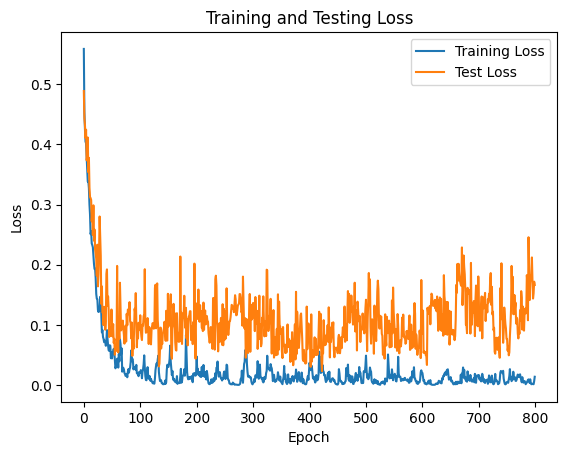

In [ ]:
# prompt: create history of training loss, and testing loss
from torch.utils.data import TensorDataset, DataLoader
import torch.nn as nn
import torch
import matplotlib.pyplot as plt
# ... (Your previous code, including the FTTransformer class and data preparation) ...

# Define the categorical cardinalities (number of unique values for each categorical feature). This is now outside the class definition
categorical_cardinalities = [filtered_df2['Pregnancies'].nunique()]

# Create the FTTransformer model
model = FTTransformer(
    numerical_features=NUMERIC_FEATURES,
    categorical_cardinalities=categorical_cardinalities
)

# Define the loss function and optimizer
criterion = nn.BCELoss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)

# Create a DataLoader for the training data
train_dataset = TensorDataset(
    torch.tensor(X_train[NUMERIC_FEATURES].values.astype('float32')),
    torch.tensor(X_train[CATEGORICAL_FEATURES].values.astype('int64')),
    torch.tensor(y_train.values.astype('float32'))
)
train_loader = DataLoader(train_dataset, batch_size=128, shuffle=True)

# Train the model and collect loss history
num_epochs = 800
train_losses = []
test_losses = []

for epoch in range(num_epochs):
    model.train()
    train_loss_epoch = 0
    for numerical_data, categorical_data, labels in train_loader:
        optimizer.zero_grad()
        outputs = model(numerical_data, categorical_data).squeeze()
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        train_loss_epoch += loss.item()

    train_losses.append(train_loss_epoch / len(train_loader))
    print(f"Epoch [{epoch+1}/{num_epochs}], Train Loss: {train_losses[-1]:.4f}")

    # Evaluate on test data and collect test loss
    model.eval()
    with torch.no_grad():
        numerical_data_test = torch.tensor(X_test[NUMERIC_FEATURES].values.astype('float32'))
        categorical_data_test = torch.tensor(X_test[CATEGORICAL_FEATURES].values.astype('int64'))
        test_outputs = model(numerical_data_test, categorical_data_test).squeeze()
        test_loss = criterion(test_outputs, torch.tensor(y_test.values.astype('float32')))
        test_losses.append(test_loss.item())
        print(f"Test Loss: {test_losses[-1]:.4f}")


# Plotting training and testing loss
plt.plot(train_losses, label='Training Loss')
plt.plot(test_losses, label='Test Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Training and Testing Loss')
plt.legend()
plt.savefig('train_test_loss.eps', format='eps', dpi = 1200)
plt.show()

# ... (Rest of your evaluation code) ...


In [ ]:
print(model)

FTTransformer(
  (embeddings): ModuleList(
    (0): Embedding(15, 128)
  )
  (numerical_linear): Linear(in_features=7, out_features=128, bias=True)
  (encoder_layer): TransformerEncoderLayer(
    (self_attn): MultiheadAttention(
      (out_proj): NonDynamicallyQuantizableLinear(in_features=128, out_features=128, bias=True)
    )
    (linear1): Linear(in_features=128, out_features=256, bias=True)
    (dropout): Dropout(p=0.1, inplace=False)
    (linear2): Linear(in_features=256, out_features=128, bias=True)
    (norm1): LayerNorm((128,), eps=1e-05, elementwise_affine=True)
    (norm2): LayerNorm((128,), eps=1e-05, elementwise_affine=True)
    (dropout1): Dropout(p=0.1, inplace=False)
    (dropout2): Dropout(p=0.1, inplace=False)
  )
  (transformer_encoder): TransformerEncoder(
    (layers): ModuleList(
      (0-1): 2 x TransformerEncoderLayer(
        (self_attn): MultiheadAttention(
          (out_proj): NonDynamicallyQuantizableLinear(in_features=128, out_features=128, bias=True)
    

/usr/local/lib/python3.10/dist-packages/torch/nn/modules/transformer.py:307: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.self_attn.batch_first was not True(use batch_first for better inference performance)
  warnings.warn(f"enable_nested_tensor is True, but self.use_nested_tensor is False because {why_not_sparsity_fast_path}")


Epoch [1/800], AUC: 0.8125
Epoch [2/800], AUC: 0.8274
Epoch [3/800], AUC: 0.8510
Epoch [4/800], AUC: 0.8690
Epoch [5/800], AUC: 0.8828
Epoch [6/800], AUC: 0.8997
Epoch [7/800], AUC: 0.9038
Epoch [8/800], AUC: 0.9096
Epoch [9/800], AUC: 0.9001
Epoch [10/800], AUC: 0.9188
Epoch [11/800], AUC: 0.9368
Epoch [12/800], AUC: 0.9229
Epoch [13/800], AUC: 0.9328
Epoch [14/800], AUC: 0.9462
Epoch [15/800], AUC: 0.9496
Epoch [16/800], AUC: 0.9482
Epoch [17/800], AUC: 0.9547
Epoch [18/800], AUC: 0.9621
Epoch [19/800], AUC: 0.9570
Epoch [20/800], AUC: 0.9678
Epoch [21/800], AUC: 0.9737
Epoch [22/800], AUC: 0.9731
Epoch [23/800], AUC: 0.9826
Epoch [24/800], AUC: 0.9848
Epoch [25/800], AUC: 0.9785
Epoch [26/800], AUC: 0.9700
Epoch [27/800], AUC: 0.9579
Epoch [28/800], AUC: 0.9850
Epoch [29/800], AUC: 0.9798
Epoch [30/800], AUC: 0.9781
Epoch [31/800], AUC: 0.9824
Epoch [32/800], AUC: 0.9832
Epoch [33/800], AUC: 0.9822
Epoch [34/800], AUC: 0.9911
Epoch [35/800], AUC: 0.9927
Epoch [36/800], AUC: 0.9807
E

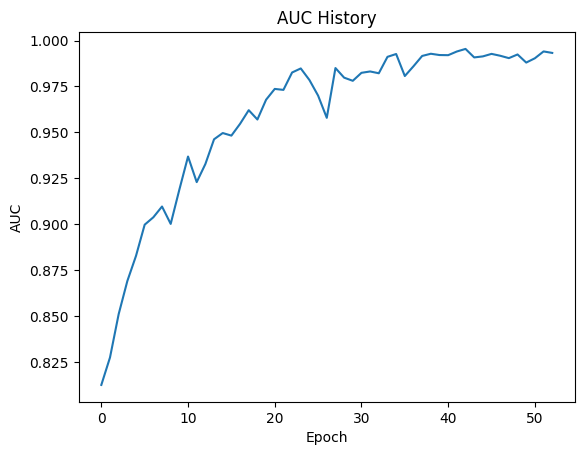

In [ ]:
# prompt: calculate time training, plot AUC history,  epochs = 800, learning rate 0.001, early_stopping_patience

import time
import torch
from torch.utils.data import TensorDataset, DataLoader
from sklearn.metrics import roc_auc_score
import matplotlib.pyplot as plt

# ... (Your previous code, including the FTTransformer class and data preparation) ...

# Define the categorical cardinalities (number of unique values for each categorical feature). This is now outside the class definition
categorical_cardinalities = [filtered_df2['Pregnancies'].nunique()]

# Create the FTTransformer model
model = FTTransformer(
    numerical_features=NUMERIC_FEATURES,
    categorical_cardinalities=categorical_cardinalities
)

# Define the loss function and optimizer
criterion = nn.BCELoss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)

# Create a DataLoader for the training data
train_dataset = TensorDataset(
    torch.tensor(X_train[NUMERIC_FEATURES].values.astype('float32')),
    torch.tensor(X_train[CATEGORICAL_FEATURES].values.astype('int64')),
    torch.tensor(y_train.values.astype('float32'))
)
train_loader = DataLoader(train_dataset, batch_size=128, shuffle=True)

# Train the model with early stopping and AUC history
num_epochs = 800
early_stopping_patience = 10
best_val_auc = 0
epochs_no_improve = 0
auc_history = []
start_time = time.time()

for epoch in range(num_epochs):
    model.train()
    for numerical_data, categorical_data, labels in train_loader:
        optimizer.zero_grad()
        outputs = model(numerical_data, categorical_data).squeeze()
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

    # Evaluate on validation set (you'll need to split your training data further)
    model.eval()
    with torch.no_grad():
        numerical_data_test = torch.tensor(X_test[NUMERIC_FEATURES].values.astype('float32'))
        categorical_data_test = torch.tensor(X_test[CATEGORICAL_FEATURES].values.astype('int64'))
        test_outputs = model(numerical_data_test, categorical_data_test).squeeze()
        auc = roc_auc_score(y_test, test_outputs)
        auc_history.append(auc)

        if auc > best_val_auc:
            best_val_auc = auc
            epochs_no_improve = 0
        else:
            epochs_no_improve += 1

        if epochs_no_improve >= early_stopping_patience:
            print("Early stopping triggered.")
            break

    print(f"Epoch [{epoch+1}/{num_epochs}], AUC: {auc:.4f}")

end_time = time.time()
training_time = end_time - start_time
print(f"Training time: {training_time:.2f} seconds")

# Plotting AUC history
plt.plot(auc_history)
plt.xlabel("Epoch")
plt.ylabel("AUC")
plt.title("AUC History")
plt.savefig('auc_history.eps', format='eps', dpi=1200)
plt.show()


/usr/local/lib/python3.10/dist-packages/torch/nn/modules/transformer.py:307: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.self_attn.batch_first was not True(use batch_first for better inference performance)
  warnings.warn(f"enable_nested_tensor is True, but self.use_nested_tensor is False because {why_not_sparsity_fast_path}")


Epoch [1/800], AUC: 0.8242, Test Time: 0.0123 seconds
Epoch [2/800], AUC: 0.8310, Test Time: 0.0114 seconds
Epoch [3/800], AUC: 0.8582, Test Time: 0.0119 seconds
Epoch [4/800], AUC: 0.8641, Test Time: 0.0126 seconds
Epoch [5/800], AUC: 0.8836, Test Time: 0.0113 seconds
Epoch [6/800], AUC: 0.8855, Test Time: 0.0118 seconds
Epoch [7/800], AUC: 0.8954, Test Time: 0.0120 seconds
Epoch [8/800], AUC: 0.9051, Test Time: 0.0119 seconds
Epoch [9/800], AUC: 0.9019, Test Time: 0.0121 seconds
Epoch [10/800], AUC: 0.9112, Test Time: 0.0124 seconds
Epoch [11/800], AUC: 0.9070, Test Time: 0.0117 seconds
Epoch [12/800], AUC: 0.9177, Test Time: 0.0118 seconds
Epoch [13/800], AUC: 0.9357, Test Time: 0.0116 seconds
Epoch [14/800], AUC: 0.9253, Test Time: 0.0115 seconds
Epoch [15/800], AUC: 0.9426, Test Time: 0.0119 seconds
Epoch [16/800], AUC: 0.9482, Test Time: 0.0120 seconds
Epoch [17/800], AUC: 0.9525, Test Time: 0.0114 seconds
Epoch [18/800], AUC: 0.9455, Test Time: 0.0134 seconds
Epoch [19/800], AUC

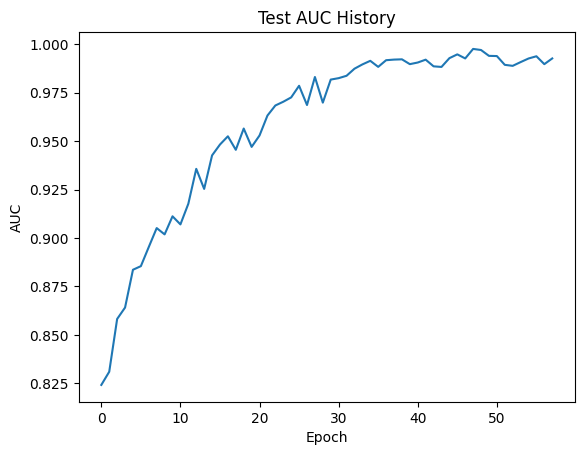

In [ ]:
# prompt: calculate test time, plot AUC history with 1200 dpi, eps;  epochs = 800, learning rate 0.001, early_stopping_patience

import matplotlib.pyplot as plt
import time
from sklearn.metrics import roc_auc_score
from matplotlib import pyplot as plt
import torch

# ... (Your previous code, including the FTTransformer class and data preparation) ...

# Define the categorical cardinalities (number of unique values for each categorical feature). This is now outside the class definition
categorical_cardinalities = [filtered_df2['Pregnancies'].nunique()]

# Create the FTTransformer model
model = FTTransformer(
    numerical_features=NUMERIC_FEATURES,
    categorical_cardinalities=categorical_cardinalities
)

# Define the loss function and optimizer
criterion = nn.BCELoss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)

# Create a DataLoader for the training data
train_dataset = TensorDataset(
    torch.tensor(X_train[NUMERIC_FEATURES].values.astype('float32')),
    torch.tensor(X_train[CATEGORICAL_FEATURES].values.astype('int64')),
    torch.tensor(y_train.values.astype('float32'))
)
train_loader = DataLoader(train_dataset, batch_size=128, shuffle=True)

# Train the model with early stopping and AUC history
num_epochs = 800
early_stopping_patience = 10
best_val_auc = 0
epochs_no_improve = 0
auc_history = []
start_time = time.time()

for epoch in range(num_epochs):
    model.train()
    for numerical_data, categorical_data, labels in train_loader:
        optimizer.zero_grad()
        outputs = model(numerical_data, categorical_data).squeeze()
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

    # Evaluate on validation set (you'll need to split your training data further)
    model.eval()
    with torch.no_grad():
        numerical_data_test = torch.tensor(X_test[NUMERIC_FEATURES].values.astype('float32'))
        categorical_data_test = torch.tensor(X_test[CATEGORICAL_FEATURES].values.astype('int64'))
        start_test_time = time.time()  # Start measuring test time
        test_outputs = model(numerical_data_test, categorical_data_test).squeeze()
        end_test_time = time.time()  # End measuring test time
        test_time = end_test_time - start_test_time
        auc = roc_auc_score(y_test, test_outputs)
        auc_history.append(auc)

        if auc > best_val_auc:
            best_val_auc = auc
            epochs_no_improve = 0
        else:
            epochs_no_improve += 1

        if epochs_no_improve >= early_stopping_patience:
            print("Early stopping triggered.")
            break

    print(f"Epoch [{epoch+1}/{num_epochs}], AUC: {auc:.4f}, Test Time: {test_time:.4f} seconds")

end_time = time.time()
training_time = end_time - start_time
print(f"Training time: {training_time:.2f} seconds")

# Plotting AUC history
plt.plot(auc_history)
plt.xlabel("Epoch")
plt.ylabel("AUC")
plt.title("Test AUC History")
plt.savefig('auc_history.eps', format='eps', dpi=1200)
plt.show()


/usr/local/lib/python3.10/dist-packages/torch/nn/modules/transformer.py:307: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.self_attn.batch_first was not True(use batch_first for better inference performance)
  warnings.warn(f"enable_nested_tensor is True, but self.use_nested_tensor is False because {why_not_sparsity_fast_path}")


Epoch [1/800], RMSE: 0.4349
Epoch [2/800], RMSE: 0.4021
Epoch [3/800], RMSE: 0.3907
Epoch [4/800], RMSE: 0.3625
Epoch [5/800], RMSE: 0.3615
Epoch [6/800], RMSE: 0.3573
Epoch [7/800], RMSE: 0.3457
Epoch [8/800], RMSE: 0.3615
Epoch [9/800], RMSE: 0.3350
Epoch [10/800], RMSE: 0.3625
Epoch [11/800], RMSE: 0.3423
Epoch [12/800], RMSE: 0.3232
Epoch [13/800], RMSE: 0.3124
Epoch [14/800], RMSE: 0.3223
Epoch [15/800], RMSE: 0.3123
Epoch [16/800], RMSE: 0.2963
Epoch [17/800], RMSE: 0.3074
Epoch [18/800], RMSE: 0.2994
Epoch [19/800], RMSE: 0.2969
Epoch [20/800], RMSE: 0.3052
Epoch [21/800], RMSE: 0.2820
Epoch [22/800], RMSE: 0.2670
Epoch [23/800], RMSE: 0.3083
Epoch [24/800], RMSE: 0.2793
Epoch [25/800], RMSE: 0.2659
Epoch [26/800], RMSE: 0.2543
Epoch [27/800], RMSE: 0.2504
Epoch [28/800], RMSE: 0.2643
Epoch [29/800], RMSE: 0.2543
Epoch [30/800], RMSE: 0.2572
Epoch [31/800], RMSE: 0.2784
Epoch [32/800], RMSE: 0.2495
Epoch [33/800], RMSE: 0.2695
Epoch [34/800], RMSE: 0.2537
Epoch [35/800], RMSE: 0

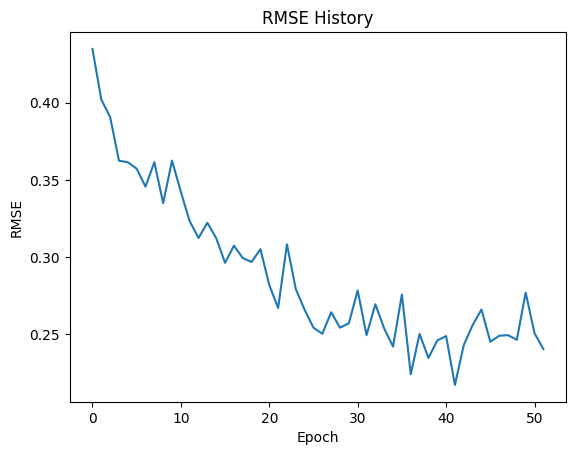

In [ ]:
# calculate output_root_mean_squared_error for FT transformer model and plot RMSE history, early stoping patience

import torch
import numpy as np
from sklearn.metrics import mean_squared_error
import matplotlib.pyplot as plt
import time


# Define the categorical cardinalities (number of unique values for each categorical feature).
categorical_cardinalities = [filtered_df2['Pregnancies'].nunique()]

# Create the FTTransformer model
model = FTTransformer(
    numerical_features=NUMERIC_FEATURES,
    categorical_cardinalities=categorical_cardinalities
)

# Define the loss function and optimizer
criterion = nn.MSELoss()  # Use Mean Squared Error Loss for regression
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)

# Create a DataLoader for the training data
train_dataset = TensorDataset(
    torch.tensor(X_train[NUMERIC_FEATURES].values.astype('float32')),
    torch.tensor(X_train[CATEGORICAL_FEATURES].values.astype('int64')),
    torch.tensor(y_train.values.astype('float32'))
)
train_loader = DataLoader(train_dataset, batch_size=128, shuffle=True)

# Train the model with early stopping and RMSE history
num_epochs = 800
early_stopping_patience = 10
best_val_rmse = float('inf')
epochs_no_improve = 0
rmse_history = []
start_time = time.time()

for epoch in range(num_epochs):
    model.train()
    for numerical_data, categorical_data, labels in train_loader:
        optimizer.zero_grad()
        outputs = model(numerical_data, categorical_data).squeeze()
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

    # Evaluate on validation set
    model.eval()
    with torch.no_grad():
        numerical_data_test = torch.tensor(X_test[NUMERIC_FEATURES].values.astype('float32'))
        categorical_data_test = torch.tensor(X_test[CATEGORICAL_FEATURES].values.astype('int64'))
        test_outputs = model(numerical_data_test, categorical_data_test).squeeze()
        rmse = np.sqrt(mean_squared_error(y_test, test_outputs.numpy()))
        rmse_history.append(rmse)

        if rmse < best_val_rmse:
            best_val_rmse = rmse
            epochs_no_improve = 0
        else:
            epochs_no_improve += 1

        if epochs_no_improve >= early_stopping_patience:
            print("Early stopping triggered.")
            break

    print(f"Epoch [{epoch+1}/{num_epochs}], RMSE: {rmse:.4f}")

end_time = time.time()
training_time = end_time - start_time
print(f"Training time: {training_time:.2f} seconds")

# Plotting RMSE history
plt.plot(rmse_history)
plt.xlabel("Epoch")
plt.ylabel("RMSE")
plt.title("RMSE History")
plt.savefig('rmse_history.eps', format='eps', dpi=1200)
plt.show()


Epoch [1/1000], Train Loss: 0.0050
Epoch [1/1000], Test Loss: 0.2144
Epoch [1/1000], Test RMSE: 0.1765
Epoch [2/1000], Train Loss: 0.0115
Epoch [2/1000], Test Loss: 0.2273
Epoch [2/1000], Test RMSE: 0.1823
Epoch [3/1000], Train Loss: 0.0310
Epoch [3/1000], Test Loss: 0.1708
Epoch [3/1000], Test RMSE: 0.1582
Epoch [4/1000], Train Loss: 0.0398
Epoch [4/1000], Test Loss: 0.2073
Epoch [4/1000], Test RMSE: 0.1980
Epoch [5/1000], Train Loss: 0.0286
Epoch [5/1000], Test Loss: 0.2097
Epoch [5/1000], Test RMSE: 0.1949
Epoch [6/1000], Train Loss: 0.0083
Epoch [6/1000], Test Loss: 0.2029
Epoch [6/1000], Test RMSE: 0.1877
Epoch [7/1000], Train Loss: 0.0086
Epoch [7/1000], Test Loss: 0.2530
Epoch [7/1000], Test RMSE: 0.1827
Epoch [8/1000], Train Loss: 0.0049
Epoch [8/1000], Test Loss: 0.3027
Epoch [8/1000], Test RMSE: 0.2046
Epoch [9/1000], Train Loss: 0.0045
Epoch [9/1000], Test Loss: 0.1787
Epoch [9/1000], Test RMSE: 0.1725
Epoch [10/1000], Train Loss: 0.0166
Epoch [10/1000], Test Loss: 0.2049
Ep

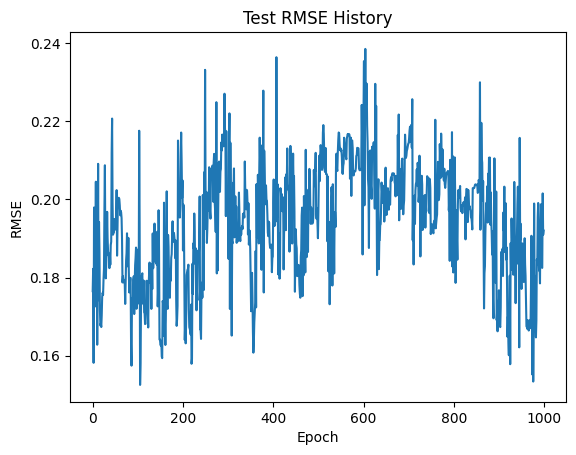

Final Test RMSE: 0.1920


In [ ]:

# Train the model with early stopping and RMSE history
num_epochs = 800
early_stopping_patience = 10
best_val_accuracy = 0
epochs_no_improve = 0
train_loss_history = []
test_loss_history = []
rmse_history = []

for epoch in range(num_epochs):
    model.train()
    train_loss_epoch = 0
    for numerical_data, categorical_data, labels in train_loader:
        optimizer.zero_grad()
        outputs = model(numerical_data, categorical_data).squeeze()
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        train_loss_epoch += loss.item()
    train_loss_history.append(train_loss_epoch / len(train_loader))
    print(f"Epoch [{epoch+1}/{num_epochs}], Train Loss: {train_loss_epoch / len(train_loader):.4f}")

    model.eval()
    test_loss_epoch = 0
    with torch.no_grad():
        all_test_outputs = []
        all_test_labels = []
        for numerical_data, categorical_data, labels in test_loader:
            outputs = model(numerical_data, categorical_data).squeeze()
            loss = criterion(outputs, labels)
            test_loss_epoch += loss.item()
            all_test_outputs.extend(outputs.tolist())
            all_test_labels.extend(labels.tolist())

        test_loss_history.append(test_loss_epoch / len(test_loader))
        print(f"Epoch [{epoch+1}/{num_epochs}], Test Loss: {test_loss_epoch / len(test_loader):.4f}")

        # Calculate RMSE and add to history
        rmse = np.sqrt(np.mean((np.array(all_test_labels) - np.array(all_test_outputs))**2))
        rmse_history.append(rmse)
        print(f"Epoch [{epoch+1}/{num_epochs}], Test RMSE: {rmse:.4f}")


# Plot the RMSE history
plt.plot(rmse_history)
plt.xlabel('Epoch')
plt.ylabel('RMSE')
plt.title('Test RMSE History')
plt.show()
plt.savefig('rmse_history.eps', format='eps', dpi=1200)
# Output the final RMSE
print(f"Final Test RMSE: {rmse:.4f}")


ExactExplainer explainer: 373it [1:51:42, 18.02s/it]


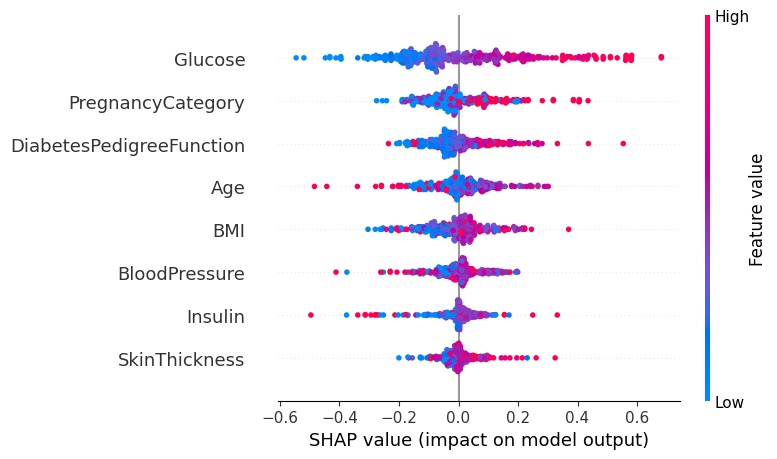

AttributeError: 'ExactExplainer' object has no attribute 'expected_value'

In [ ]:
class ModelWrapper:
    def __init__(self, model):
        self.model = model

    def predict(self, data):
        # Split the data into numerical and categorical parts
        numerical_data = torch.tensor(data[:, :len(NUMERIC_FEATURES)], dtype=torch.float32)
        categorical_data = torch.tensor(data[:, len(NUMERIC_FEATURES):], dtype=torch.int64)

        # Predict using the model and convert to numpy
        with torch.no_grad():
            predictions = self.model(numerical_data, categorical_data).squeeze().numpy()
        return predictions

# Combine numerical and categorical data for SHAP
X_test_combined = pd.concat([X_test[NUMERIC_FEATURES], X_test[CATEGORICAL_FEATURES]], axis=1).values

# Create the model wrapper
model_wrapper = ModelWrapper(model)

# Create SHAP explainer
explainer = shap.Explainer(model_wrapper.predict, X_test_combined)

# Calculate SHAP values for the test set
shap_values = explainer(X_test_combined)

# Summary plot for SHAP values
shap.summary_plot(shap_values, X_test_combined, feature_names=NUMERIC_FEATURES + CATEGORICAL_FEATURES)

# Example of SHAP force plot for a single instance
shap.force_plot(explainer.expected_value, shap_values[0, :], X_test_combined[0, :], feature_names=NUMERIC_FEATURES + CATEGORICAL_FEATURES)


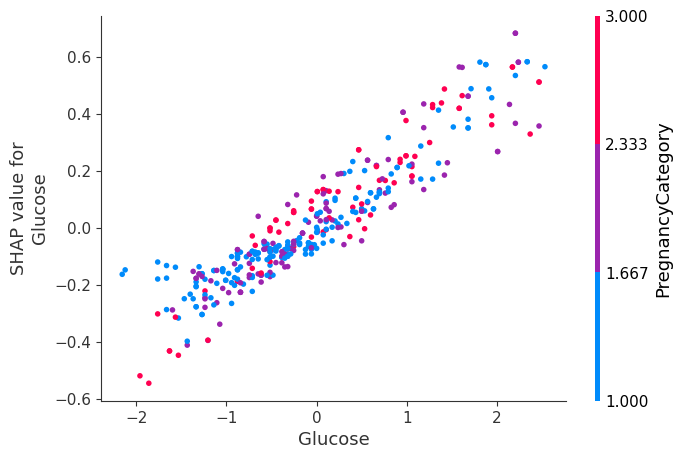

In [ ]:
# SHAP dependence plot for a specific feature
shap.dependence_plot("Glucose", shap_values.values, X_test_combined, feature_names=NUMERIC_FEATURES + CATEGORICAL_FEATURES)


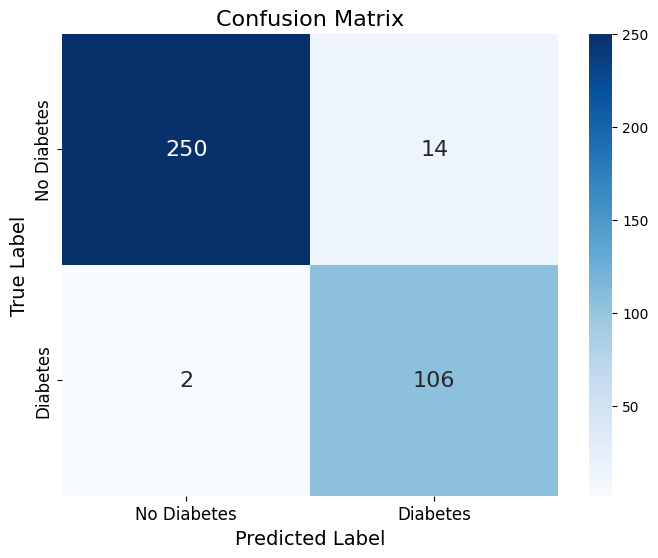

In [ ]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

# Assuming you have predicted labels (predicted_labels_test) and true labels (y_test)
cm = confusion_matrix(y_test, predicted_labels_test)

# Plot the confusion matrix as a heatmap with larger text in cells
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=['No Diabetes', 'Diabetes'],
            yticklabels=['No Diabetes', 'Diabetes'],
            annot_kws={"size": 16})  # Increase text size in cells

plt.xlabel('Predicted Label', fontsize=14)
plt.ylabel('True Label', fontsize=14)
plt.title('Confusion Matrix', fontsize=16)
plt.xticks(fontsize=12)  # Increase x-axis label size
plt.yticks(fontsize=12)  # Increase y-axis label size
plt.savefig('confusion_matrix.eps', format='eps', dpi=300, bbox_inches='tight')
plt.show()



In [ ]:

class ModelWrapper:
    def __init__(self, model):
        self.model = model

    def predict_proba(self, data):
        # Split the data into numerical and categorical parts
        numerical_data = torch.tensor(data[:, :len(NUMERIC_FEATURES)], dtype=torch.float32)
        categorical_data = torch.tensor(data[:, len(NUMERIC_FEATURES):], dtype=torch.int64)

        # Predict using the model and convert to numpy
        with torch.no_grad():
            predictions = self.model(numerical_data, categorical_data).squeeze().numpy()
        return np.column_stack((1 - predictions, predictions))  # Return probabilities for both classes

# Combine numerical and categorical data for LIME
X_test_combined = pd.concat([X_test[NUMERIC_FEATURES], X_test[CATEGORICAL_FEATURES]], axis=1).values

# Create the model wrapper
model_wrapper = ModelWrapper(model)

# Create LIME explainer
explainer = LimeTabularExplainer(
    X_test_combined,
    feature_names=NUMERIC_FEATURES + CATEGORICAL_FEATURES,
    class_names=['No Diabetes', 'Diabetes'],
    mode='classification'
)

# Choose an instance to explain
instance_idx = 0
instance = X_test_combined[instance_idx]

# Explain the prediction for the chosen instance
explanation = explainer.explain_instance(
    instance,
    model_wrapper.predict_proba,
    num_features=10  # Number of features to show in the explanation
)

# Generate the LIME plot
explanation.show_in_notebook(show_table=True)
explanation.at_list()

NameError: name 'X_test' is not defined

In [ ]:
#tabnet #xgboost, random forest, svm, logistic regression


In [ ]:
# Train and evaluate TabNet
tabnet_model = TabNetClassifier(
    n_d=64, n_a=64, n_steps=3, gamma=1.5,
    n_independent=2, n_shared=2,
    lambda_sparse=1e-4, optimizer_fn=torch.optim.Adam,
    optimizer_params=dict(lr=0.001),
    scheduler_params={"step_size":50, "gamma":0.9},
    scheduler_fn=torch.optim.lr_scheduler.StepLR,
    mask_type='entmax'
)


tabnet_model.fit(
    X_train.values, y_train.values,
    eval_set=[(X_test.values, y_test.values)],
    max_epochs=400, patience=20,
    batch_size=128, virtual_batch_size=128,
    num_workers=0,
    weights=1,
    drop_last=False
)

y_pred_tabnet = tabnet_model.predict(X_test.values)
accuracy_tabnet = accuracy_score(y_test, y_pred_tabnet)
precision_tabnet = precision_score(y_test, y_pred_tabnet)
recall_tabnet = recall_score(y_test, y_pred_tabnet)
f1_tabnet = f1_score(y_test, y_pred_tabnet)

/usr/local/lib/python3.10/dist-packages/pytorch_tabnet/abstract_model.py:82: UserWarning: Device used : cpu
  warnings.warn(f"Device used : {self.device}")


epoch 0  | loss: 0.85196 | val_0_auc: 0.70295 |  0:00:00s
epoch 1  | loss: 0.56262 | val_0_auc: 0.70502 |  0:00:01s
epoch 2  | loss: 0.51223 | val_0_auc: 0.7184  |  0:00:01s
epoch 3  | loss: 0.44998 | val_0_auc: 0.74006 |  0:00:01s
epoch 4  | loss: 0.43682 | val_0_auc: 0.77711 |  0:00:02s
epoch 5  | loss: 0.44489 | val_0_auc: 0.78613 |  0:00:02s
epoch 6  | loss: 0.41809 | val_0_auc: 0.78651 |  0:00:03s
epoch 7  | loss: 0.39706 | val_0_auc: 0.82025 |  0:00:03s
epoch 8  | loss: 0.38402 | val_0_auc: 0.85213 |  0:00:04s
epoch 9  | loss: 0.38271 | val_0_auc: 0.86637 |  0:00:04s
epoch 10 | loss: 0.35385 | val_0_auc: 0.88107 |  0:00:05s
epoch 11 | loss: 0.35766 | val_0_auc: 0.88605 |  0:00:05s
epoch 12 | loss: 0.35962 | val_0_auc: 0.90569 |  0:00:06s
epoch 13 | loss: 0.35304 | val_0_auc: 0.91277 |  0:00:06s
epoch 14 | loss: 0.31242 | val_0_auc: 0.9099  |  0:00:07s
epoch 15 | loss: 0.31175 | val_0_auc: 0.92459 |  0:00:07s
epoch 16 | loss: 0.29933 | val_0_auc: 0.92221 |  0:00:08s
epoch 17 | los

/usr/local/lib/python3.10/dist-packages/pytorch_tabnet/callbacks.py:172: UserWarning: Best weights from best epoch are automatically used!
  warnings.warn(wrn_msg)


In [ ]:
log_clf = LogisticRegression()
rnd_clf = RandomForestClassifier()
xgb_clf = XGBClassifier()
lgb_clf = lgb.LGBMClassifier()
from sklearn.metrics import accuracy_score
for clf in (log_clf, rnd_clf, lgb_clf, xgb_clf):
    clf.fit(X_train, y_train)
    y_pred = clf.predict(X_test)

[LightGBM] [Info] Number of positive: 513, number of negative: 973
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000915 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 856
[LightGBM] [Info] Number of data points in the train set: 1486, number of used features: 8
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.345222 -> initscore=-0.640108
[LightGBM] [Info] Start training from score -0.640108


In [ ]:

# Logistic Regression
y_pred_log = log_clf.predict(X_test)
accuracy_log = accuracy_score(y_test, y_pred_log)
precision_log = precision_score(y_test, y_pred_log)
recall_log = recall_score(y_test, y_pred_log)
f1_log = f1_score(y_test, y_pred_log)

start_time = time.time()
end_time = time.time()
test_time_log = end_time - start_time


# Random Forest
y_pred_rnd = rnd_clf.predict(X_test)
accuracy_rnd = accuracy_score(y_test, y_pred_rnd)
precision_rnd = precision_score(y_test, y_pred_rnd)
recall_rnd = recall_score(y_test, y_pred_rnd)
f1_rnd = f1_score(y_test, y_pred_rnd)
# Random Forest
start_time = time.time()
end_time = time.time()
test_time_rnd = end_time - start_time

# XGBoost
y_pred_xgb = xgb_clf.predict(X_test)
accuracy_xgb = accuracy_score(y_test, y_pred_xgb)
precision_xgb = precision_score(y_test, y_pred_xgb)
recall_xgb = recall_score(y_test, y_pred_xgb)
f1_xgb = f1_score(y_test, y_pred_xgb)
# XGBoost
start_time = time.time()
end_time = time.time()
test_time_xgb = end_time - start_time

# TabNet
y_pred_tabnet = clf.predict(X_test)
accuracy_tabnet = accuracy_score(y_test, y_pred_tabnet)
precision_tabnet = precision_score(y_test, y_pred_tabnet)
recall_tabnet = recall_score(y_test, y_pred_tabnet)
f1_tabnet = f1_score(y_test, y_pred_tabnet)

# TabNet
start_time = time.time()
end_time = time.time()
test_time_tabnet = end_time - start_time

# LGBM
y_pred_lgb = lgb_clf.predict(X_test)
accuracy_lgb = accuracy_score(y_test, y_pred_lgb)
precision_lgb = precision_score(y_test, y_pred_lgb)
recall_lgb = recall_score(y_test, y_pred_lgb)
f1_lgb = f1_score(y_test, y_pred_lgb)

start_time = time.time()
end_time = time.time()
test_time_lgbm = end_time - start_time

# FTTransformer
start_time = time.time()
numerical_data_test = torch.tensor(X_test[NUMERIC_FEATURES].values.astype('float32'))
categorical_data_test = torch.tensor(X_test[CATEGORICAL_FEATURES].values.astype('int64'))
test_outputs = model(numerical_data_test, categorical_data_test).squeeze()
predicted_labels = (test_outputs > 0.5).int().numpy()
end_time = time.time()
test_time_ft = end_time - start_time

y_pred_ft = predicted_labels
accuracy_ft = accuracy_score(y_test, y_pred_ft)
precision_ft = precision_score(y_test, y_pred_ft)
recall_ft = recall_score(y_test, y_pred_ft)
f1_ft = f1_score(y_test, y_pred_ft)


# Create a DataFrame to display the results
results_df = pd.DataFrame({
    'Model': ['Logistic Regression', 'Random Forest', 'XGBoost', 'TabNet', 'LGBM', 'FTTransformer'],
    'Accuracy': [accuracy_log, accuracy_rnd, accuracy_xgb, accuracy_tabnet, accuracy_lgb, accuracy_ft],
    'Precision': [precision_log, precision_rnd, precision_xgb, precision_tabnet, precision_lgb, precision_ft],
    'Recall': [recall_log, recall_rnd, recall_xgb, recall_tabnet, recall_lgb, recall_ft],
    'F1-Score': [f1_log, f1_rnd, f1_xgb, f1_tabnet, f1_lgb, f1_ft],
    'Test Time (seconds)': [test_time_log, test_time_rnd, test_time_xgb, test_time_tabnet, test_time_lgbm, test_time_ft]
})

# Display the DataFrame
print(results_df)

                 Model  Accuracy  Precision    Recall  F1-Score  \
0  Logistic Regression  0.774194   0.622449  0.564815  0.592233   
1        Random Forest  0.973118   0.945455  0.962963  0.954128   
2              XGBoost  0.965054   0.905983  0.981481  0.942222   
3               TabNet  0.965054   0.905983  0.981481  0.942222   
4                 LGBM  0.965054   0.905983  0.981481  0.942222   
5        FTTransformer  0.935484   0.881818  0.898148  0.889908   

   Test Time (seconds)  
0             0.000060  
1             0.000056  
2             0.000076  
3             0.000039  
4             0.000051  
5             0.024090  


In [ ]:
final_roc_auc = []

In [ ]:
# Convert Pandas DataFrame to NumPy arrays
X_train = X_train.to_numpy() if isinstance(X_train, pd.DataFrame) else X_train
X_test = X_test.to_numpy()  if isinstance(X_test, pd.DataFrame) else X_test
y_train = y_train.to_numpy()  if isinstance(y_train, pd.Series) else y_train
y_test = y_test.to_numpy() if isinstance(y_test, pd.Series) else y_test

In [ ]:
filtered_df2.describe()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
count,1858.000000,1.858000e+03,1.858000e+03,1.858000e+03,1.858000e+03,1.858000e+03,1.858000e+03,1.858000e+03,1858.000000
mean,3.754575,2.053120e-09,-2.566400e-10,1.026560e-09,8.212480e-09,-4.106240e-09,-3.079680e-09,2.053120e-09,0.334230
std,3.258896,1.000269e+00,1.000269e+00,1.000269e+00,1.000269e+00,1.000269e+00,1.000269e+00,1.000269e+00,0.471848
min,0.000000,-2.549754e+00,-4.034651e+00,-2.644880e+00,-1.713120e+00,-2.185291e+00,-1.234876e+00,-1.036520e+00,0.000000
25%,1.000000,-7.466507e-01,-6.894134e-01,-5.538267e-01,-4.147781e-01,-7.434663e-01,-7.097952e-01,-7.816204e-01,0.000000
50%,3.000000,-1.565443e-01,-2.036585e-02,0.000000e+00,0.000000e+00,-2.841504e-02,-2.930273e-01,-3.567869e-01,0.000000
75%,6.000000,6.302642e-01,6.486817e-01,4.301983e-01,0.000000e+00,6.436550e-01,4.604513e-01,6.628133e-01,1.000000
max,14.000000,2.531718e+00,4.161181e+00,2.521252e+00,7.301084e+00,2.894308e+00,5.832126e+00,4.061481e+00,1.000000


In [ ]:
filtered_df2.info()

<class 'pandas.core.frame.DataFrame'>
Index: 1858 entries, 0 to 1999
Data columns (total 9 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Pregnancies               1858 non-null   int64  
 1   Glucose                   1858 non-null   float32
 2   BloodPressure             1858 non-null   float32
 3   SkinThickness             1858 non-null   float32
 4   Insulin                   1858 non-null   float32
 5   BMI                       1858 non-null   float32
 6   DiabetesPedigreeFunction  1858 non-null   float32
 7   Age                       1858 non-null   float32
 8   Outcome                   1858 non-null   int64  
dtypes: float32(7), int64(2)
memory usage: 94.4 KB


In [ ]:
print(X_test.dtype)

float32


In [ ]:
print(X_train.dtype)

float32


In [ ]:
print(y_train.dtype)

int64


In [ ]:
print(y_test.dtype)

int64


In [ ]:
if isinstance(X_train, np.ndarray):
    X_train = pd.DataFrame(X_train)
if isinstance(X_test, np.ndarray):
    X_test = pd.DataFrame(X_test)

In [ ]:
X_train = X_train.apply(pd.to_numeric, errors='coerce')
X_test = X_test.apply(pd.to_numeric, errors='coerce')

In [ ]:
# Convert back to NumPy arrays with float32 type
X_train = X_train.values.astype(np.float32)
X_test = X_test.values.astype(np.float32)

In [ ]:
# Verify the conversion
print("X_train dtype after conversion:", X_train.dtype)  # Should be float32
print("X_test dtype after conversion:", X_test.dtype)    # Should be float32
print("X_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)

X_train dtype after conversion: float32
X_test dtype after conversion: float32
X_train shape: (1486, 8)
X_test shape: (372, 8)


In [ ]:
# Train the TabNet model with the cleaned data
tabnet_model.fit(
    X_train, y_train.values,  # Ensure y_train is a NumPy array or Series
    eval_set=[(X_test, y_test.values)],  # Ensure y_test is a NumPy array or Series
    max_epochs=400, patience=20,
    batch_size=128, virtual_batch_size=128,
    num_workers=0,
    weights=1,
    drop_last=False
)

AttributeError: 'numpy.ndarray' object has no attribute 'values'

ROC AUC for TabNet model: 0.9893


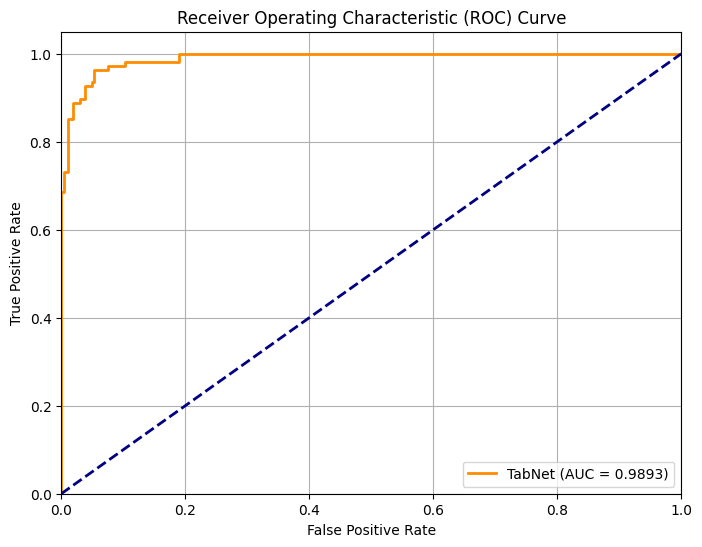

In [ ]:
# Step 1: Calculate the predicted probabilities for the test set
# Assuming that `tabnet_model.predict_proba` returns probabilities for both classes
y_pred_proba_tabnet = tabnet_model.predict_proba(X_test)[:, 1]  # Probabilities for the positive class

# Step 2: Calculate ROC AUC score
roc_auc_tabnet = roc_auc_score(y_test, y_pred_proba_tabnet)
print(f"ROC AUC for TabNet model: {roc_auc_tabnet:.4f}")

# Step 3: Calculate the ROC curve
fpr_tabnet, tpr_tabnet, _ = roc_curve(y_test, y_pred_proba_tabnet)

# Step 4: Plot the ROC curve
plt.figure(figsize=(8, 6))
plt.plot(fpr_tabnet, tpr_tabnet, color='darkorange', lw=2, label=f'TabNet (AUC = {roc_auc_tabnet:.4f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (ROC) Curve')
plt.legend(loc="lower right")
plt.grid()
plt.show()


ROC AUC for FTTransformer model: 0.9245


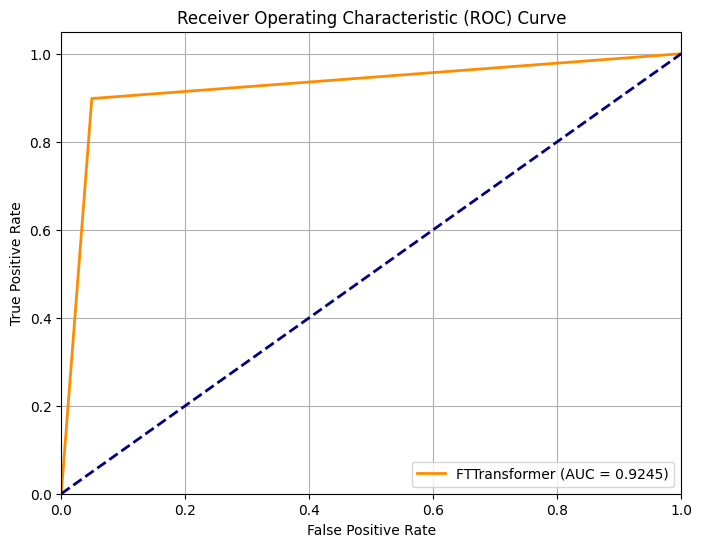

In [ ]:
#plot AUC ROC of FT transformer model with learning rate 0.001, epochs 800, batch size = 128

# Calculate ROC AUC score
roc_auc_ft_transformer = roc_auc_score(y_test, predicted_labels)  # Replace predicted_labels with your actual predicted labels
print(f"ROC AUC for FTTransformer model: {roc_auc_ft_transformer:.4f}")

# Calculate the ROC curve
fpr_ft_transformer, tpr_ft_transformer, _ = roc_curve(y_test, predicted_labels)

# Plot the ROC curve
plt.figure(figsize=(8, 6))
plt.plot(fpr_ft_transformer, tpr_ft_transformer, color='darkorange', lw=2, label=f'FTTransformer (AUC = {roc_auc_ft_transformer:.4f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (ROC) Curve')
plt.legend(loc="lower right")
plt.grid()
plt.show()


/usr/local/lib/python3.10/dist-packages/sklearn/base.py:493: UserWarning: X does not have valid feature names, but LogisticRegression was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.10/dist-packages/sklearn/base.py:493: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(


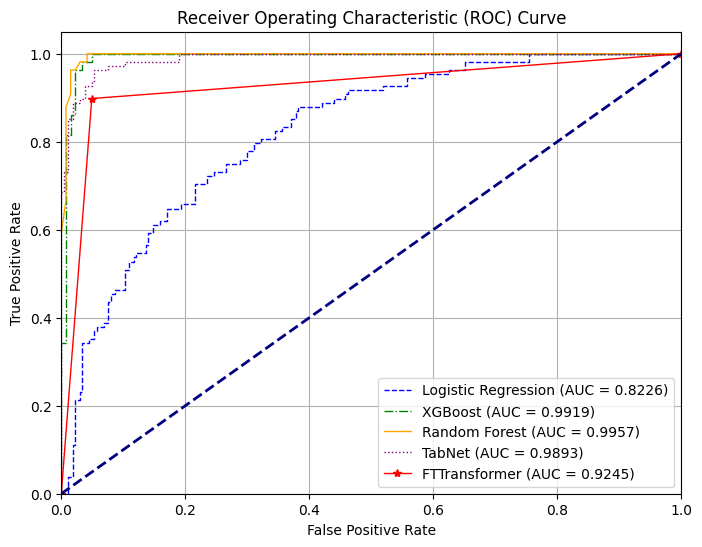

In [ ]:
from matplotlib.markers import MarkerStyle

# Logistic Regression
y_pred_proba_log = log_clf.predict_proba(X_test)[:, 1]
roc_auc_log = roc_auc_score(y_test, y_pred_proba_log)
fpr_log, tpr_log, _ = roc_curve(y_test, y_pred_proba_log)

# XGBoost
y_pred_proba_xgb = xgb_clf.predict_proba(X_test)[:, 1]
roc_auc_xgb = roc_auc_score(y_test, y_pred_proba_xgb)
fpr_xgb, tpr_xgb, _ = roc_curve(y_test, y_pred_proba_xgb)

# Random Forest
y_pred_proba_rnd = rnd_clf.predict_proba(X_test)[:, 1]
roc_auc_rnd = roc_auc_score(y_test, y_pred_proba_rnd)
fpr_rnd, tpr_rnd, _ = roc_curve(y_test, y_pred_proba_rnd)

# TabNet
y_pred_proba_tabnet = tabnet_model.predict_proba(X_test)[:, 1]
roc_auc_tabnet = roc_auc_score(y_test, y_pred_proba_tabnet)
fpr_tabnet, tpr_tabnet, _ = roc_curve(y_test, y_pred_proba_tabnet)

# FTTransformer
roc_auc_ft_transformer = roc_auc_score(y_test, predicted_labels)
fpr_ft_transformer, tpr_ft_transformer, _ = roc_curve(y_test, predicted_labels)

# Plot all ROC curves
plt.figure(figsize=(8, 6))
plt.plot(fpr_log, tpr_log, color='blue', lw=1, linestyle = '--', label=f'Logistic Regression (AUC = {roc_auc_log:.4f})')
plt.plot(fpr_xgb, tpr_xgb, color='green', lw=1, linestyle = '-.', label=f'XGBoost (AUC = {roc_auc_xgb:.4f})')
plt.plot(fpr_rnd, tpr_rnd, color='orange', lw=1, linestyle = '-', label=f'Random Forest (AUC = {roc_auc_rnd:.4f})')
plt.plot(fpr_tabnet, tpr_tabnet, color='purple', lw=1, linestyle = 'dotted', label=f'TabNet (AUC = {roc_auc_tabnet:.4f})')
plt.plot(fpr_ft_transformer, tpr_ft_transformer, color='red', lw=1, marker = '*' , label=f'FTTransformer (AUC = {roc_auc_ft_transformer:.4f})')

plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (ROC) Curve')
plt.legend(loc="lower right")
plt.grid()
#plt.savefig('roc_curves.eps', format='eps', dpi=1200, bbox_inches='tight')
plt.show()
